# Практическая работа №4
## Метод касательных(Ньютона)

Начальное x0 = 1.55
f(x0) = -0.032302
f'(x0) = -10.307838
Точность: 0.001

Итерация 1: x1 = 1.546866, |x1-x0| = 0.003134
Итерация 2: x2 = 1.546866, |x2-x1| = 0.000000

Точность достигнута на 2-й итерации!
Корень уравнения: x = 1.546866
Округленно: x = 1.547


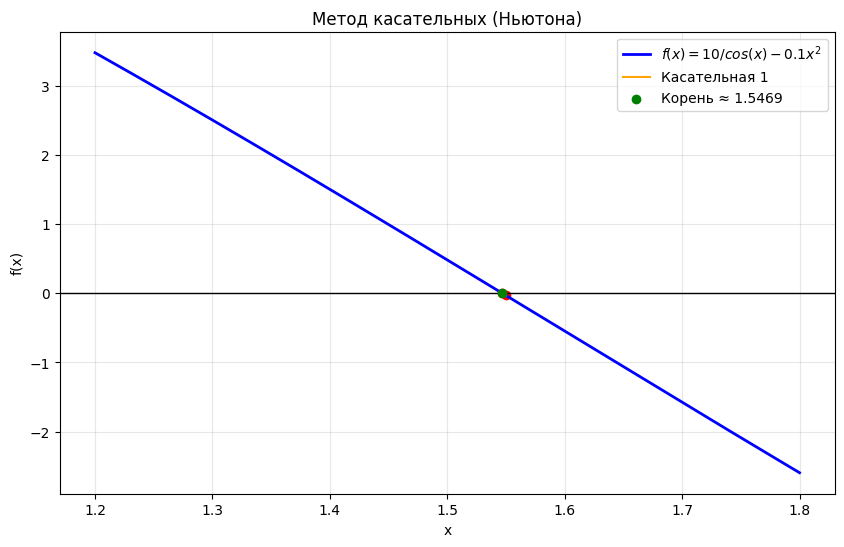

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Исходная функция
def f(x):
    return 10 * math.cos(x) - 0.1 * x * x

# Производная функции
def f_derivative(x):
    return -10 * math.sin(x) - 0.2 * x

# Начальное приближение (берем правый конец отрезка)
x = 1.55
eps = 0.001
max_iter = 20

print(f"Начальное x0 = {x}")
print(f"f(x0) = {f(x):.6f}")
print(f"f'(x0) = {f_derivative(x):.6f}")
print(f"Точность: {eps}")
print()

for i in range(max_iter):
    x_old = x
    # Формула метода касательных
    x = x_old - f(x_old) / f_derivative(x_old)
    
    print(f"Итерация {i+1}: x{i+1} = {x:.6f}, |x{i+1}-x{i}| = {abs(x - x_old):.6f}")
    
    if abs(x - x_old) < eps:
        print(f"\nТочность достигнута на {i+1}-й итерации!")
        print(f"Корень уравнения: x = {x:.6f}")
        print(f"Округленно: x = {x:.3f}")
        break
else:
    print(f"\nДостигнуто максимальное число итераций ({max_iter})")

    
# Определяем функции для графиков
def f_val(x):
    return 10 * np.cos(x) - 0.1 * x**2

def df_val(x):
    return -10 * np.sin(x) - 0.2 * x

# Настройка данных
x_range = np.linspace(1.2, 1.8, 400)
y_range = f_val(x_range)

plt.figure(figsize=(10, 6))
plt.plot(x_range, y_range, label='$f(x) = 10/cos(x) - 0.1x^2$', color='blue', linewidth=2)
plt.axhline(0, color='black', linewidth=1)

# Отрисовка шагов метода Ньютона (первые 2 итерации для наглядности)
current_x = 1.55
for i in range(2):
    y_now = f_val(current_x)
    slope = df_val(current_x)
    next_x = current_x - y_now / slope
    
    # Линия от оси X до функции
    plt.vlines(current_x, 0, y_now, color='red', linestyle='--')
    # Касательная
    tangent_x = np.array([current_x, next_x])
    tangent_y = slope * (tangent_x - current_x) + y_now
    plt.plot(tangent_x, tangent_y, color='orange', label=f'Касательная {i+1}' if i==0 else "")
    
    plt.scatter([current_x], [y_now], color='red')
    current_x = next_x

# Финальный корень
plt.scatter([current_x], [0], color='green', zorder=5, label=f'Корень ≈ {current_x:.4f}')

plt.title('Метод касательных (Ньютона)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()